In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../General_Functions/")
from BasicData import *
from Flow_functions import * # import flow functions, Information to the agent
from Geometric_functions import * # Import rotation from euler angles
from Evolution_Traj import * # Import time integration for trjectories
from Time_Int_Traj import * # Import evolution function
from BasicData import *  # Nagents, R0, V
from Strategies import * # Import strategies, Braitenberg or Triangulation
from Strategies_Evolution_MeasureNoise import * # Import strategies Evolution, Braitenberg or Triangulation
from Flow_functions import * # Import flow functions: stokeslet, grads, strains ... 


Do one step only of the integration to get the distribution of vectors

In [2]:
# Integrate numerically the angular dynamics of each strategy
# Calculate the scalar product between t at the end of the evolution
# and the real source position

def EvolutionSignalNoise(Grad, NPoints, NTrials, Intensity):

    # Function to evaluate the scalar product between t at the end of the evolution
    # and the real source position
    #input:
    # Gradient (source flow measured)
    #output:
    # dot product as a 2D map
    # variance of dot product as 2D map
    
    # Noise intensity
    
    # t axis for Triangulation strategy with roll
    t0_T, t1_T, t2_T = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))
    
    # Resulting dot products
    DotProduct_T = np.zeros((NPoints, NPoints, NTrials))

    for k in range(NPoints):
        for i in range(NPoints):
            AgentPosition =  np.array([z[k], x[i], 0.])

            for trials_i in range(NTrials):
                # Random orientation of agent axis
                alpha, beta, gamma = (2 * np.random.rand(3) - 1) * np.pi
                RotationMatrix = Rotation(alpha, np.abs(beta), gamma)

                n_T = np.dot(RotationMatrix,[0, 1, 0])
                b_T = np.dot(RotationMatrix,[0, 0, 1])
                t_T = np.dot(RotationMatrix,[1, 0, 0])

                # Time integration of strategies
                for time in range(Duration):
                    Target_T = Evolution_Triangulation_TestNoise(n_T, b_T, t_T, AntennaeLength, AgentPosition, Grad, e3, dt, roll, Intensity)
                   
                t0_T[k, i, trials_i], t1_T[k, i, trials_i], t2_T[k, i, trials_i] = Target_T
                
    return t0_T, t1_T, t2_T

In [11]:
# Data
NPoints = 1 # Grid number of points per axis
Duration = 1 # Number of timesteps of the numerical integration
NTrials = 100 # Number of trial x point

AntennaeLength = .001 # Sensors distance, on antennae
BodyWidth = .1 # Sensors distance along body
x = np.array([0.3]) # x axis
z = np.array([0.3]) # z axis

e3 = np.array([1, 0, 0]) # Source flow axis of symmetry, scheme zxy
dt = 1 # Timesteps 
roll = .3 # Roll Intensity

diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane
diocane


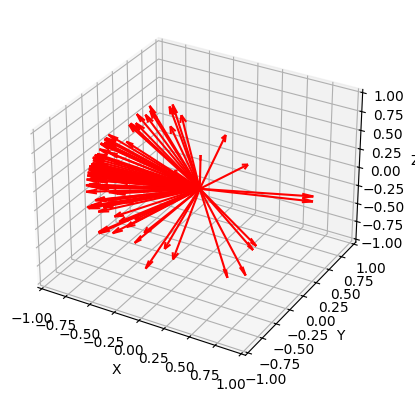

In [12]:
# Calculate and save data

# Information flow 
GradName = ['GradientStokeslet'] # 'GradientStresslet', 'ShearStokeslet', 'GradientStokeslet'
Grads = [GradientStokeslet] # GradientStresslet, ShearStokeslet, GradientStokeslet] 


t0_T, t1_T, t2_T = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))
for grads_i, Grad in enumerate(Grads):
    Intensity = 0*0.000005*np.linalg.norm(Grad(e3, np.array([2,0,0])))
    t0_T, t1_T, t2_T = EvolutionSignalNoise(Grad, NPoints, NTrials, Intensity)
    # Set up figure and image grid

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot vectors from the origin (0,0,0)
ax.quiver(0, 0, 0, t0_T, t1_T, t2_T, color=['r'], arrow_length_ratio=0.1)

# Labels and limits
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Show the plot
plt.show()